# ___Phylogenetic PCA___
---------------------------

In [1]:
print(R.version$version.string)

[1] "R version 4.6.1 (2026-06-24 ucrt)"


In [2]:
suppressPackageStartupMessages({  
    library("ape")
    library("phytools")
    library("phylobase")
    library("adephylo")
    library("readxl")
})

In [3]:
packageVersion("phylobase")

[1] '0.8.12'

In [4]:
packageVersion("adephylo")

[1] '1.1.17'

In [5]:
states <- as.data.frame(readxl::read_xlsx("../../data/chapter2/FRED/subsets/final.xlsx", sheet = "final")[, c("binominal", "state")])
states$binominal <- gsub(states$binominal, pattern = ' ', replacement = '_')
data <- read.csv("../../data/chapter2/FRED/subsets/continuous_raw.csv")
phylogeny <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre")

stopifnot(all(states$binominal %in% data$binominal))
stopifnot(all(states$binominal %in% phylogeny$tip.label))

In [6]:
averages <- aggregate(x = data[, c("F00679", "F00727", "F00709")], by = list(data$binominal), FUN = mean, simplify = TRUE) # species averages
averages[, -1] <- apply(averages[, -1], FUN = log, MARGIN = 2) |> apply(FUN = scale, MARGIN = 2, center = TRUE, scale = TRUE) # log transform and standardize the values (Z scores)

rownames(averages) <- averages$`Group.1` # set the species names as the row names
averages <- averages[, -1] # drop that column
head(averages)

,F00679,F00727,F00709
,<dbl>,<dbl>,<dbl>
Abies_alba,0.63510885,0.02600399,-0.15239477
Abies_nephrolepis,0.01896267,-0.12243122,0.05612151
Acacia_auriculiformis,0.37989941,0.16110758,0.12948648
Acacia_crassicarpa,-1.28984464,1.09570276,0.44532467
Acacia_mangium,-1.05031695,1.01870522,0.11186091
Acer_barbinerve,-1.05244676,1.34409226,-0.87602769


In [7]:
APG4_GYMNOSPERMS <- c("Cycadaceae", "Zamiaceae", "Ginkgoaceae", "Ephedraceae", "Welwitschiaceae", "Gnetaceae", "Pinaceae", "Araucariaceae", "Podocarpaceae", "Sciadopityaceae", "Taxaceae", "Cupressaceae")

# ferns
APG4_MONILOPHYTES <- c("Equisetaceae", "Ophioglossaceae", "Psilotaceae", "Marattiaceae", "Osmundaceae", "Hymenophyllaceae", "Gleicheniaceae", "Matoniaceae", "Dipteridaceae", "Anemiaceae", "Lygodiaceae", "Schizaeaceae", "Marsileaceae", "Salviniaceae", "Cyatheaceae", "Cibotiaceae", "Dicksoniaceae", "Metaxyaceae", "Thyrsopteridaceae", "Loxsomataceae", "Culcitaceae", "Plagiogyriaceae",
                     "Saccolomataceae", "Cystodiaceae", "Lonchitidaceae", "Lindsaeaceae", "Pteridaceae", "Dennstaedtiaceae", "Polypodiaceae", "Davalliaceae", "Didymochlaenaceae", "Dryopteridaceae", "Hypodematiaceae", "Lomariopsidaceae", "Oleandraceae", "Tectariaceae", "Aspleniaceae", "Athyriaceae", "Blechnaceae", "Cystopteridaceae", "Desmophlebiaceae", "Diplaziopsidaceae", "Hemidictyaceae",
                     "Onocleaceae", "Rhachidosoraceae", "Thelypteridaceae", "Woodsiaceae")

APG4_LYCOPHYTES <- c("Lycopodiaceae", "Isoetaceae", "Selaginellaceae")

STATE_COLOURS <- c(AM = "#E7BC0C", EcM = "#23B9AF", ErM = "#6B6CF2", NM = "#11E823", NMAM = "#2D2E30", EcMAM = "#E71A23")

apg4 <- merge(x = readxl::read_xlsx("../../data/chapter2/FRED/subsets/final.xlsx", sheet = "final")[, c("binominal", "F01289")], # species names and family names
              y = read.csv("../../data/chapter2/APG4_angiosperms_taxonomy.csv"), # APG4 categorizations for Angiosperms
              by.x = "F01289", by.y = "family", all.x = TRUE)

apg4[apg4$F01289 %in% APG4_GYMNOSPERMS, "group"] <- "gymnosperms"
apg4[apg4$F01289 == "Cephalotaxaceae", "group"] <- "gymnosperms"
apg4[apg4$F01289 %in% APG4_MONILOPHYTES, "group"] <- "ferns"
apg4[apg4$F01289 %in% APG4_LYCOPHYTES, "group"] <- "lycophytes"
apg4[apg4$F01289 == "Viburnaceae", "group"] <- "asterids" # https://en.wikipedia.org/wiki/Adoxaceae

apg4$binominal <- gsub(apg4$binominal, pattern = ' ', replacement = '_') 

# colour list from - https://sashamaps.net/docs/resources/20-colors/
APG4_COLOURS <- c(lamiids = "#e6194b", asterids = "#3cb44b", superrosids = "#911eb4", superasterids = "#f58231", monocots = "#743700", malvids = "#FFE17E", magnoliids = "#747D81",
                  campanulids = "#bcf60c", gymnosperms = "#fabebe",  ferns = "#e6beff", eudicots = "#004FFF", fabids = "#aaffc3", rosids = "#808000", angiosperms = "#FF05FF", lycophytes = "#009EF7")

APG4_HIGHER_RANKS <- c("asterids", "superrosids", "superasterids", "rosids", "eudicots", "angiosperms")

In [8]:
apg4[is.na(apg4$group), ] # good :)

F01289,binominal,order,group
<chr>,<chr>,<chr>,<chr>


In [8]:
apg4$group |> table()


  angiosperms      asterids   campanulids      eudicots        fabids 
            5            86           128            19           262 
        ferns   gymnosperms       lamiids    lycophytes    magnoliids 
           30            83           122             1           140 
      malvids      monocots        rosids superasterids   superrosids 
          219            86            95            12            13 

## ___`phytools::phyl.pca`___
---------------------

In [9]:
# https://besjournals.onlinelibrary.wiley.com/doi/10.1111/1365-2435.14739
# https://github.com/dgkontopoulos/Kontopoulos_et_al_torpor_evolution_2025/blob/main/Code/run_phylogenetic_pca.R

pcomps <- phytools::phyl.pca(tree = phylogeny, method = "lambda", Y = averages) # phylogenetic PCA using phytools

In [14]:
summary(pcomps)

Importance of components:
                             PC1        PC2        PC3
Standard deviation     0.1026166 0.07513227 0.02080151
Proportion of Variance 0.6340522 0.33989349 0.02605430
Cumulative Proportion  0.6340522 0.97394570 1.00000000


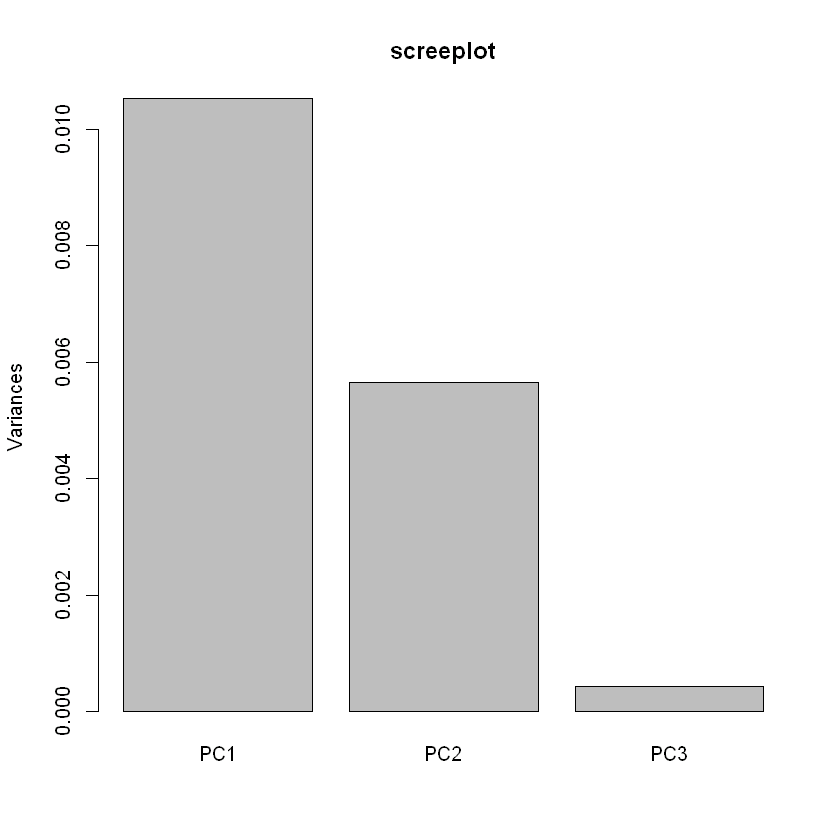

In [15]:
plot(pcomps)

In [30]:
# the Evec attribute is the loading in phylogenetic PCA from phytools - https://blog.phytools.org/2017/03/loadings-in-phylpca-vs-loadings-in.html
pcomps$Evec

,PC1,PC2,PC3
F00679,0.6349584,-0.53559953,-0.5567414
F00727,-0.6933324,-0.07719993,-0.7164708
F00709,0.3407610,0.84093597,-0.4203672


In [32]:
str(pcomps$S) # these are aour loadings

 num [1:1301, 1:3] 0.497 0.28 0.338 -1.263 -1.171 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:1301] "Abies_alba" "Abies_nephrolepis" "Acacia_auriculiformis" "Acacia_crassicarpa" ...
  ..$ : chr [1:3] "PC1" "PC2" "PC3"


In [33]:
ppca <- as.data.frame(pcomps$S)
ppca$binominal <- rownames(ppca)
rownames(ppca) <- NULL
ppca <- merge(x = ppca, y = states, by = "binominal") # merge the mycorrhizal states column

head(ppca)

,binominal,PC1,PC2,PC3,state
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,Abies_alba,0.4974335,0.1468412,-0.38632880,EcM
2,Abies_nephrolepis,0.2801755,0.6636568,-0.02459863,EcM
3,Acacia_auriculiformis,0.3377686,0.5101453,-0.45953456,EcMAM
4,Acacia_crassicarpa,-1.2628092,1.5979085,-0.33229710,EcMAM
5,Acacia_mangium,-1.1709656,1.1951401,-0.27030834,EcMAM
6,Acer_barbinerve,-1.7345532,0.3404099,-0.08697691,AM


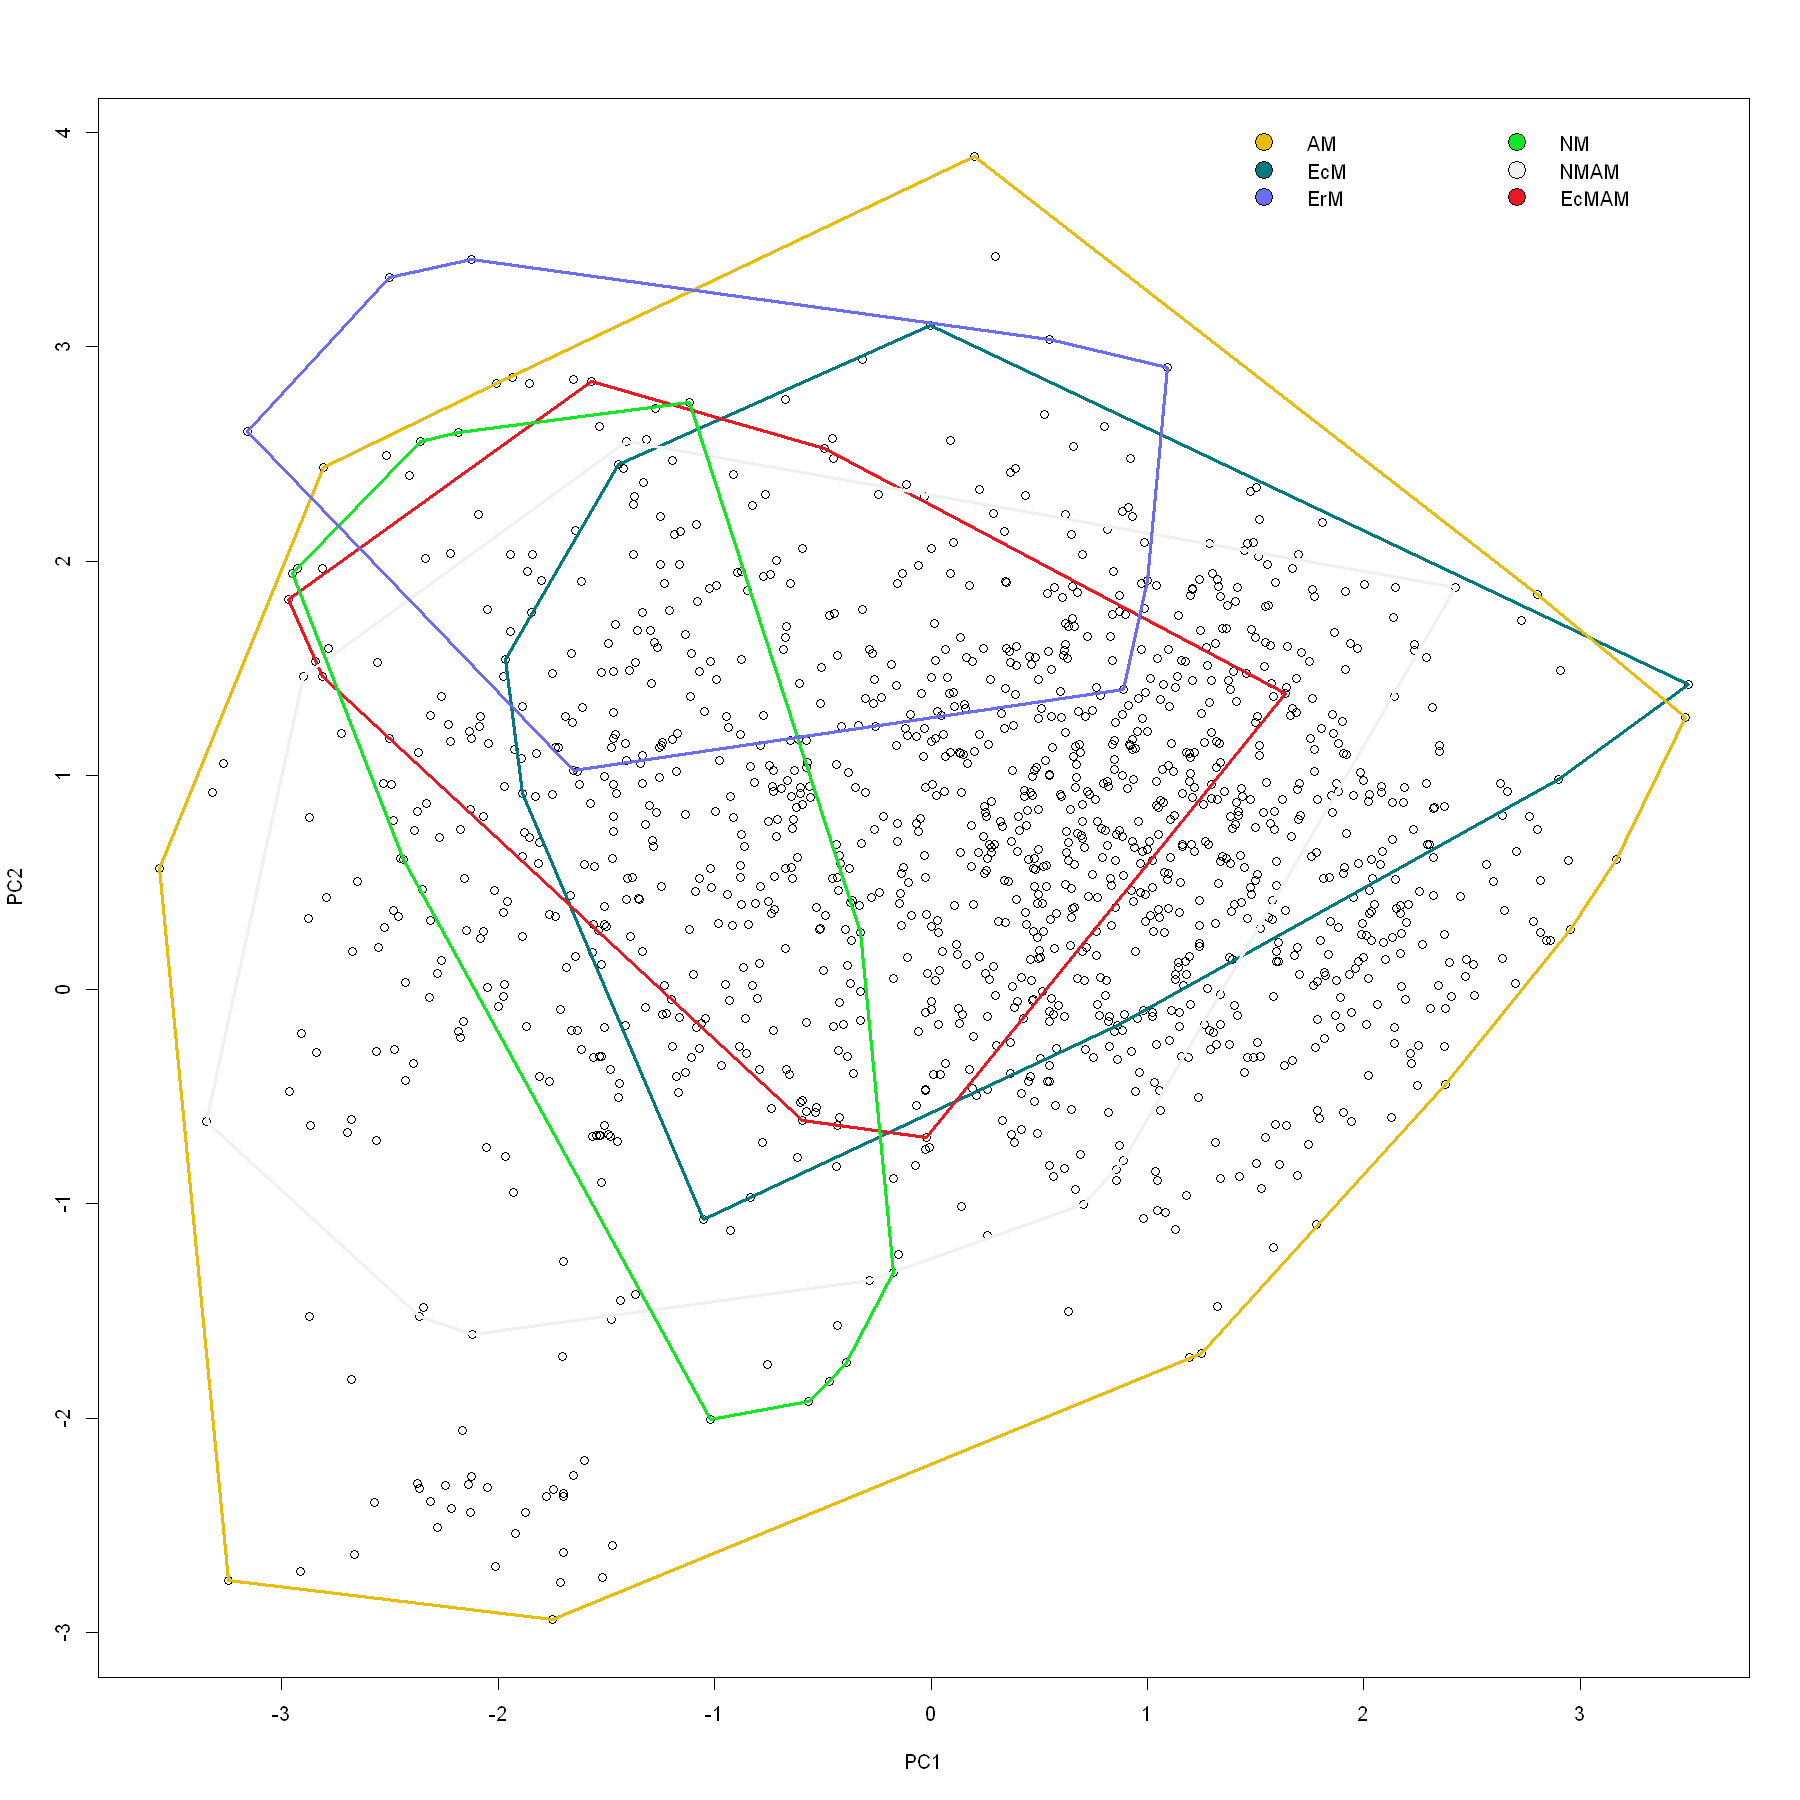

In [41]:
options(repr.plot.width = 15, repr.plot.height = 15)


plot(ppca$PC1, ppca$PC2, xlab = "PC1", ylab = "PC2", pch = 21)

for (s in unique(ppca$state)){
    scores <- subset(ppca, state == s, select = c("PC1", "PC2", "state")) # subset the dataframe to only include species of the choosen state
    # plotting convex hulls in R - https://chitchatr.wordpress.com/2011/12/30/convex-hull-around-scatter-plot-in-r/
    indices <- chull(x = scores$PC1, y = scores$PC2) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC1[indices], scores$PC2[indices], col = STATE_COLOURS[s], lwd = 2.5)
}

legend("topright", legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 21, pt.cex = 2, horiz = FALSE, ncol = 2, bty = "n", y.intersp = 0.45)

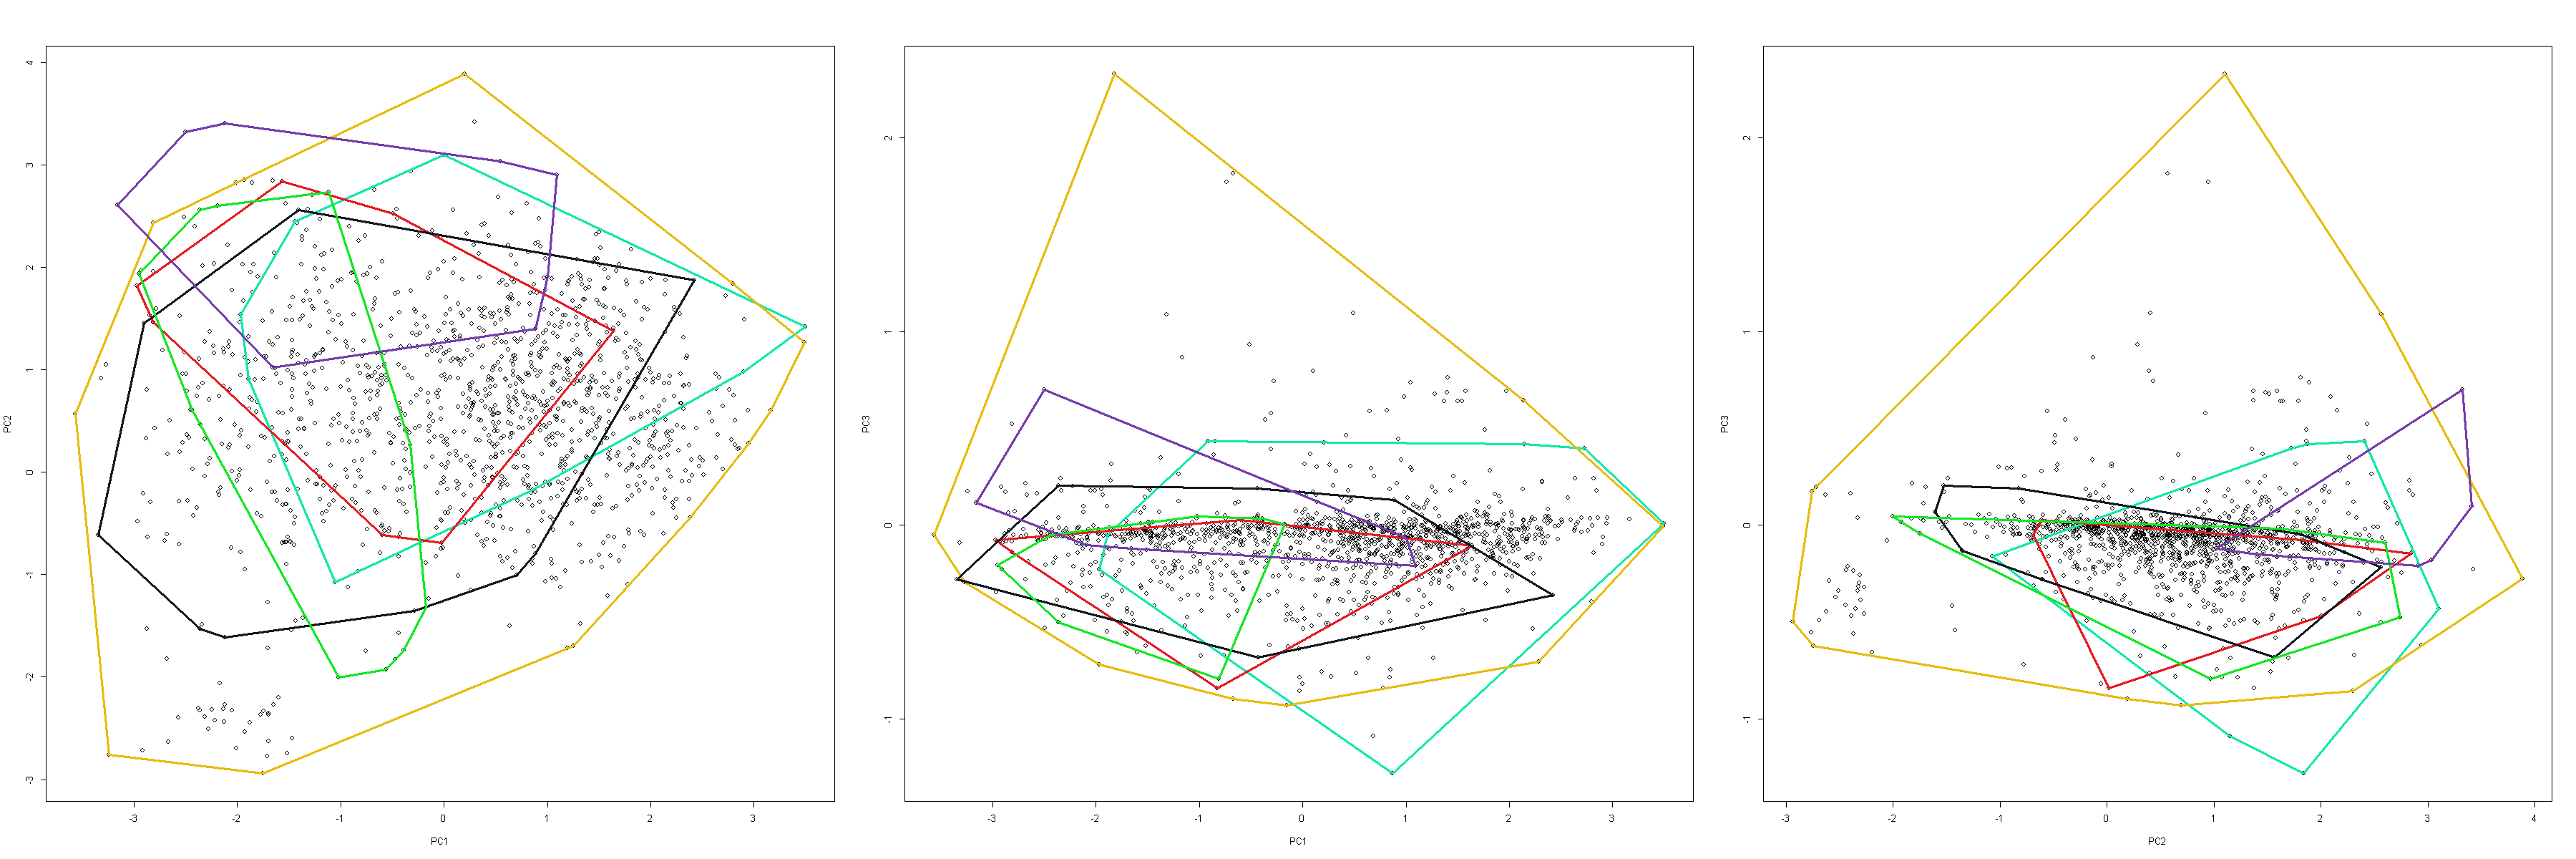

In [91]:
# try including all the 3 PCs

par(mfrow = c(1, 3))
options(repr.plot.width = 30, repr.plot.height = 10)

plot(ppca$PC1, ppca$PC2, xlab = "PC1", ylab = "PC2", pch = 21)
for (s in unique(ppca$state)){
    scores <- subset(ppca, state == s, select = c("PC1", "PC2")) # subset the dataframe to only include species of the choosen state
    indices <- chull(x = scores$PC1, y = scores$PC2) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC1[indices], scores$PC2[indices], col = STATE_COLOURS[s], lwd = 2.5)
}

plot(ppca$PC1, ppca$PC3, xlab = "PC1", ylab = "PC3", pch = 21)
for (s in unique(ppca$state)){
    scores <- subset(ppca, state == s, select = c("PC1", "PC3")) # subset the dataframe to only include species of the choosen state
    indices <- chull(x = scores$PC1, y = scores$PC3) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC1[indices], scores$PC3[indices], col = STATE_COLOURS[s], lwd = 2.5)
}

plot(ppca$PC2, ppca$PC3, xlab = "PC2", ylab = "PC3", pch = 21)
for (s in unique(ppca$state)){
    scores <- subset(ppca, state == s, select = c("PC2", "PC3")) # subset the dataframe to only include species of the choosen state
    indices <- chull(x = scores$PC2, y = scores$PC3) # create the convex hull indices
    indices <- c(indices, indices[1])
    lines(scores$PC2[indices], scores$PC3[indices], col = STATE_COLOURS[s], lwd = 2.5)
}

## ___`adephylo::ppca`___
---------------------------

In [10]:
# https://gist.github.com/sinarueeger/718c7ec3cee473ad0beed4feea4d0e24

averages_4d <- phylobase::phylo4d(x = phylogeny, tip.data = averages)
pcomps_v2 <- adephylo::ppca(x = averages_4d, center = FALSE, scale = FALSE, # our data has already been standardized, so these should be set to FALSE
                     method = "Abouheif", nfposi = 3, # nfposi - number of eigenvalues (number of PCs) - our data only has 3 variables so PCs cannot be > 3
                            scannf = FALSE) # read the docs to see what the args mean

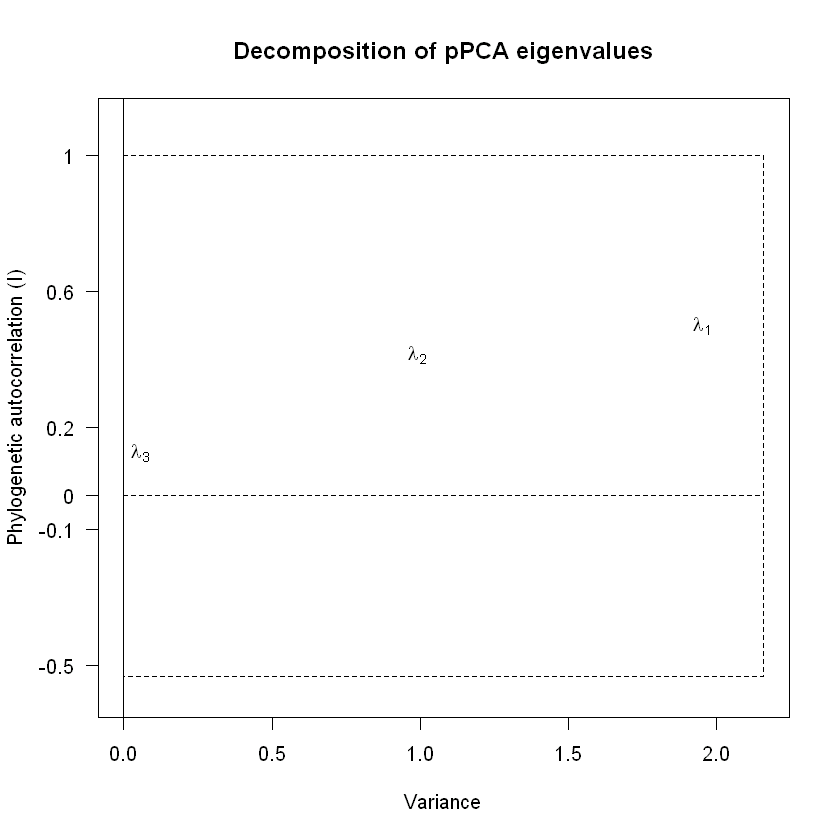

In [12]:
adephylo:::screeplot.ppca(pcomps_v2)

In [12]:
summary(pcomps_v2)


### Phylogenetic Principal Component Analysis ###

Call: adephylo::ppca(x = averages_4d, method = "Abouheif", center = FALSE, 
    scale = FALSE, scannf = FALSE, nfposi = 3)

== Moran's I statistics ==
            I0       Imin     Imax
 -0.0007692308 -0.5333333 1.000049

== PCA scores ==
              var      cum     ratio     moran
Axis 1 1.96538412 1.965384 0.6556320 0.4946060
Axis 2 0.97850015 2.943884 0.9820496 0.4279883
Axis 3 0.05380981 2.997694 1.0000000 0.1315425

== pPCA eigenvalues decomposition ==
               eig        var     moran
Axis 1 0.978904267 1.95350342 0.5011019
Axis 2 0.412129147 0.99004875 0.4162716
Axis 3 0.006922311 0.05414191 0.1278549


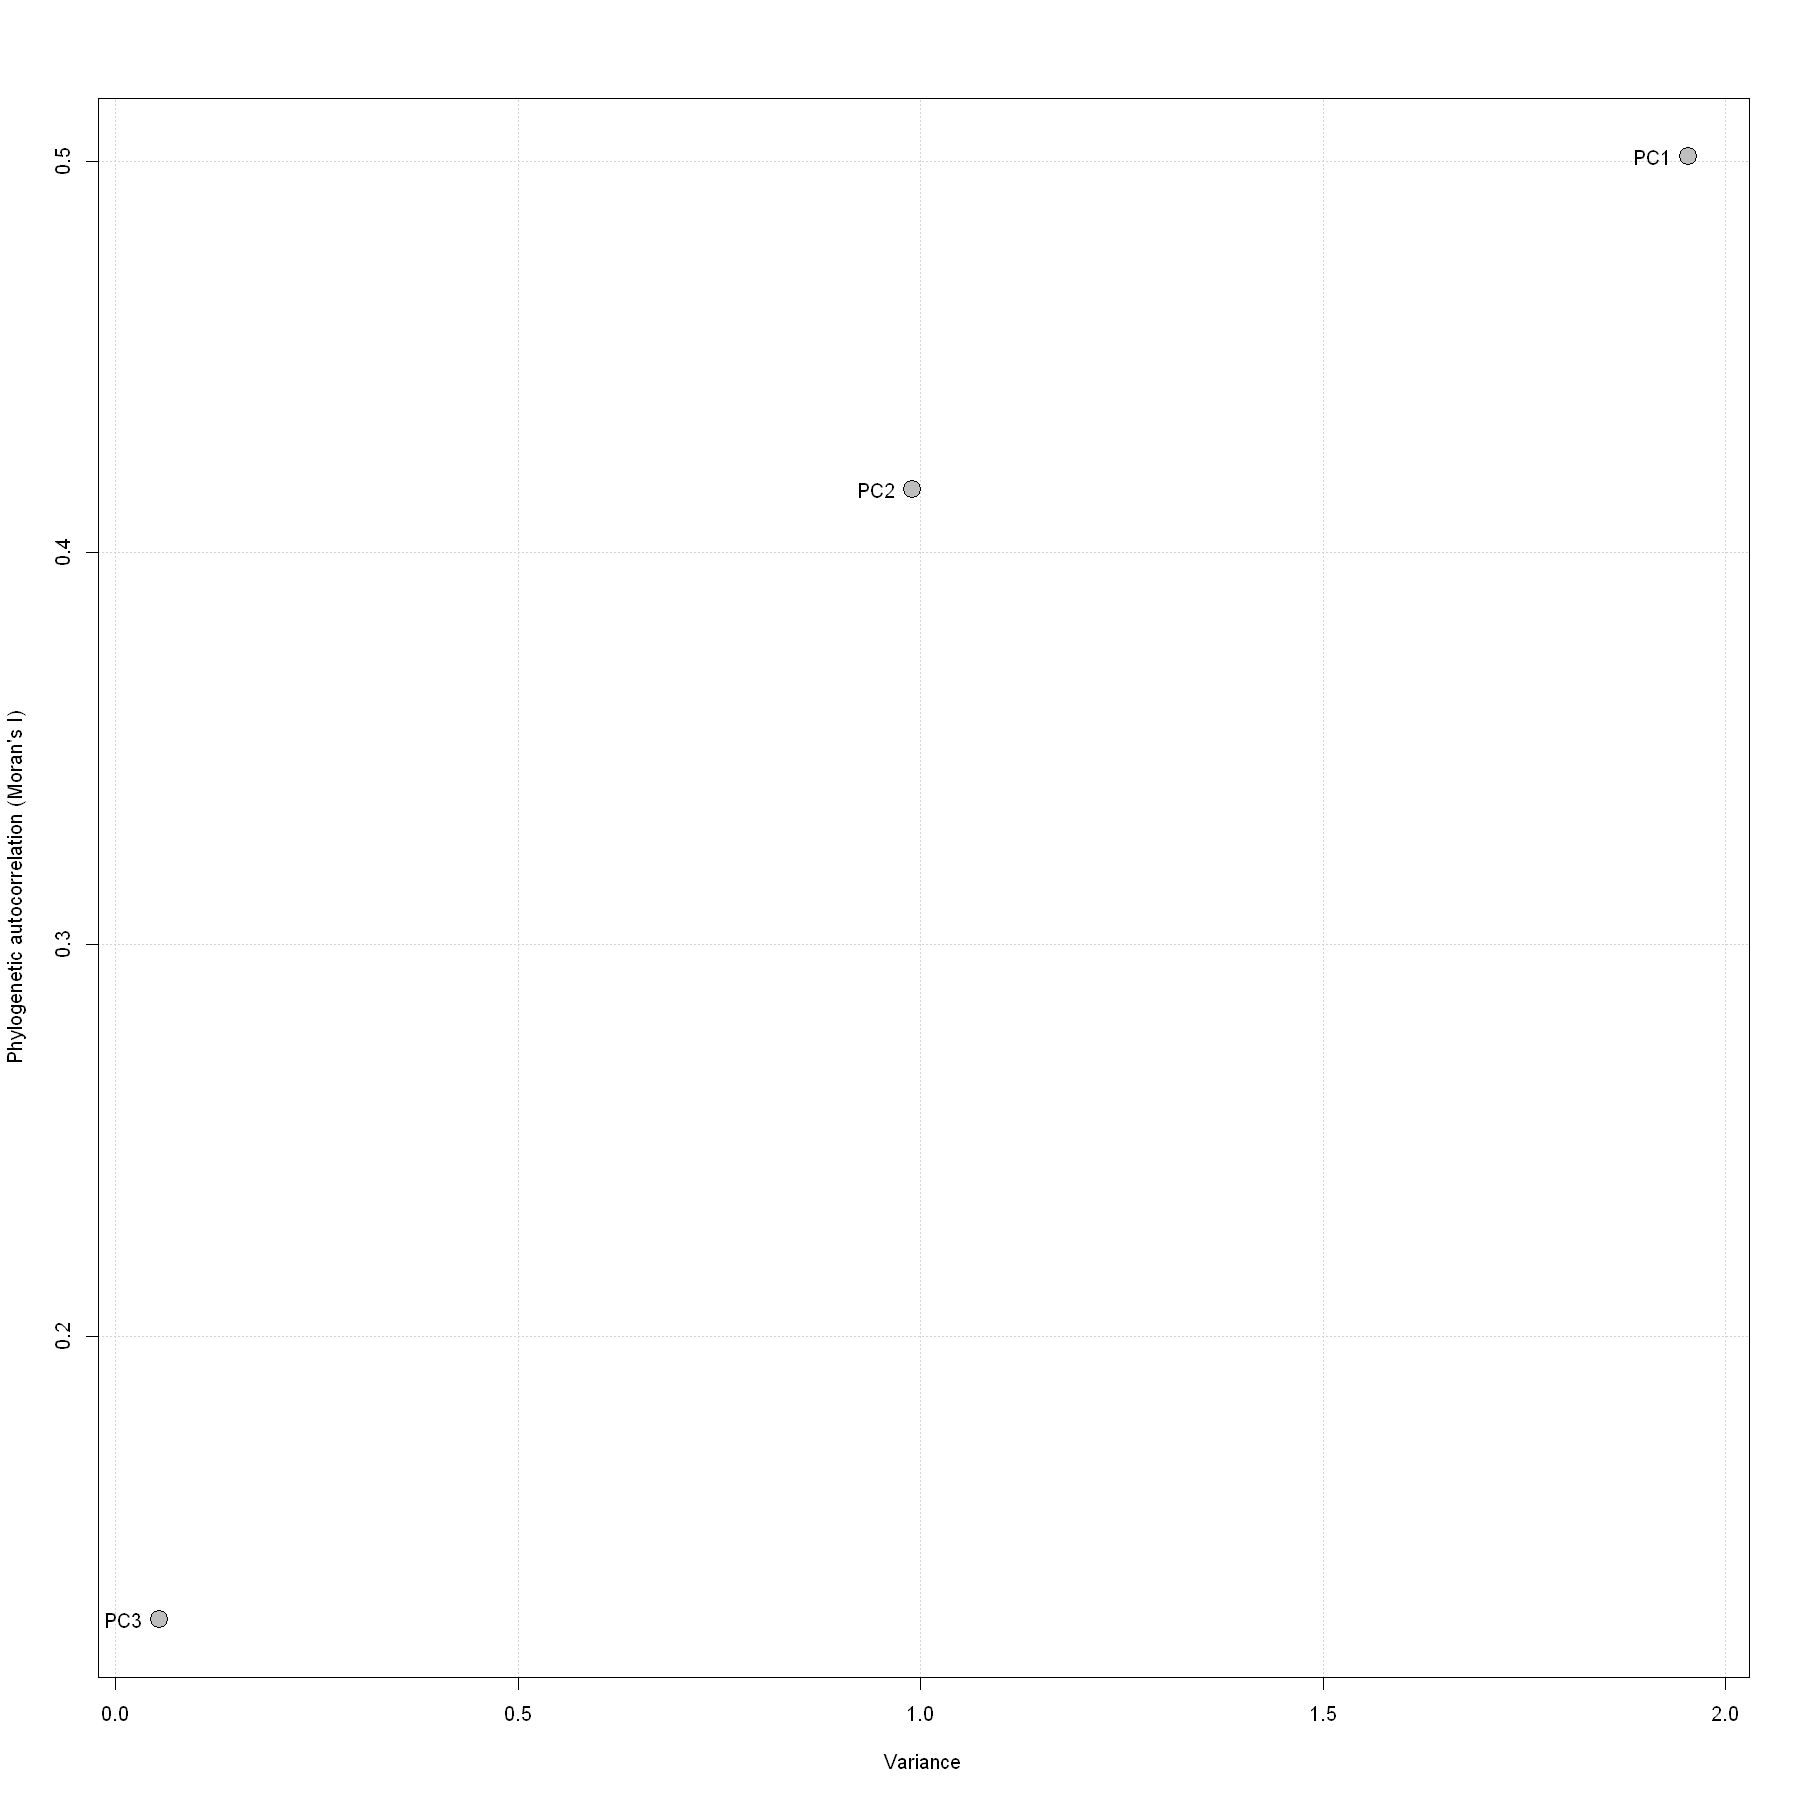

In [149]:
# https://gawainantell.com/autocorrelation-in-ecology/
plot(c(1.95350342, 0.99004875, 0.05414191), # variances
     c(0.5011019, 0.4162716, 0.1278549), # Moran's I values - phylogenetic autocorrelation - https://en.wikipedia.org/wiki/Moran%27s_I
     xlab = "Variance", ylab = "Phylogenetic autocorrelation (Moran's I)", pch = 21, bg = "grey", cex = 2, panel.first = grid())#, ylim = c(-0.5, 1))
text(x = c(1.95350342, 0.99004875, 0.05414191) - 0.045, y = c(0.5011019, 0.4162716, 0.1278549), paste0("PC", 1:3))

In [ ]:
# https://www.rdocumentation.org/packages/adephylo/versions/1.1-17/topics/ppca

In [110]:
pcomps_v2

	#############################################
	# phylogenetic Principal Component Analysis #
	#############################################
class: ppca
$call: adephylo::ppca(x = averages_4d, method = "Abouheif", center = FALSE, 
    scale = FALSE, scannf = FALSE, nfposi = 3)

$nfposi: 3 axes-components saved
$nfnega: 0 axes-components saved
$kept.axes: index of kept axes
Positive eigenvalues: 0.9789 0.4121 0.006922
Negative eigenvalues: 0.006922

  vector length mode    content    
1 $eig   3      numeric eigenvalues

  data.frame nrow ncol content                                             
1 $c1        3    3    principal axes: scaled vectors of traits loadings   
2 $li        1301 3    principal components: coordinates of taxa ('scores')
3 $ls        1301 3    lag vector of principal components                  
4 $as        2    3    pca axes onto ppca axes                             

$tre: a phylogeny (class phylo4)
$prox: a matrix of phylogenetic proximities

other elements: 

In [11]:
ppcs <- pcomps_v2$li
ppcs$binominal <- rownames(ppcs)
rownames(ppcs) <- NULL
ppcs <- merge(x = ppcs, y = states, by = "binominal")
ppcs <- merge(x = ppcs, y = apg4, by = "binominal")

head(ppcs)

,binominal,PC1,PC2,PC3,state,F01289,order,group
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,Abies_alba,0.2142932,0.52884613,0.31884765,EcM,Pinaceae,NA,gymnosperms
2,Abies_nephrolepis,0.1244893,-0.01885256,-0.05143545,EcM,Pinaceae,NA,gymnosperms
3,Acacia_auriculiformis,0.1381405,0.13825816,0.38580803,EcMAM,Fabaceae,Fabales,fabids
4,Acacia_crassicarpa,-1.1773963,-1.27658639,0.21597000,EcMAM,Fabaceae,Fabales,fabids
5,Acacia_mangium,-1.1763500,-0.86274749,0.15907992,EcMAM,Fabaceae,Fabales,fabids
6,Acer_barbinerve,-1.9124577,-0.15257881,-0.02962873,AM,Sapindaceae,Sapindales,malvids


In [14]:
# what's critical here is that APG4's group column is very heterogenous in terms of rank hierarchy
# it contains very lower level groups like lamids, rosids and then slightly higher level ranks like superrosids and also very high level ranks like angiosperms and gymnosperms
# the problem with this is that a species marked as rosid WILL ALSO BE A superrosid and an angiosperm - but the group column will only say it's a rosid
# this will become problematic if we include both lower and higher level ranks in the PCA plot - where one would intuitively expect the higher ranks to overarch their lower ranks

# SO CHOOSING ONLY TO SHOW THE LOWEST RANKS

In [46]:
ppcs$order |> is.na() |> sum()

[1] 118

In [48]:
subset(ppcs, !is.na(order))$order |> unique() |> length()

[1] 42

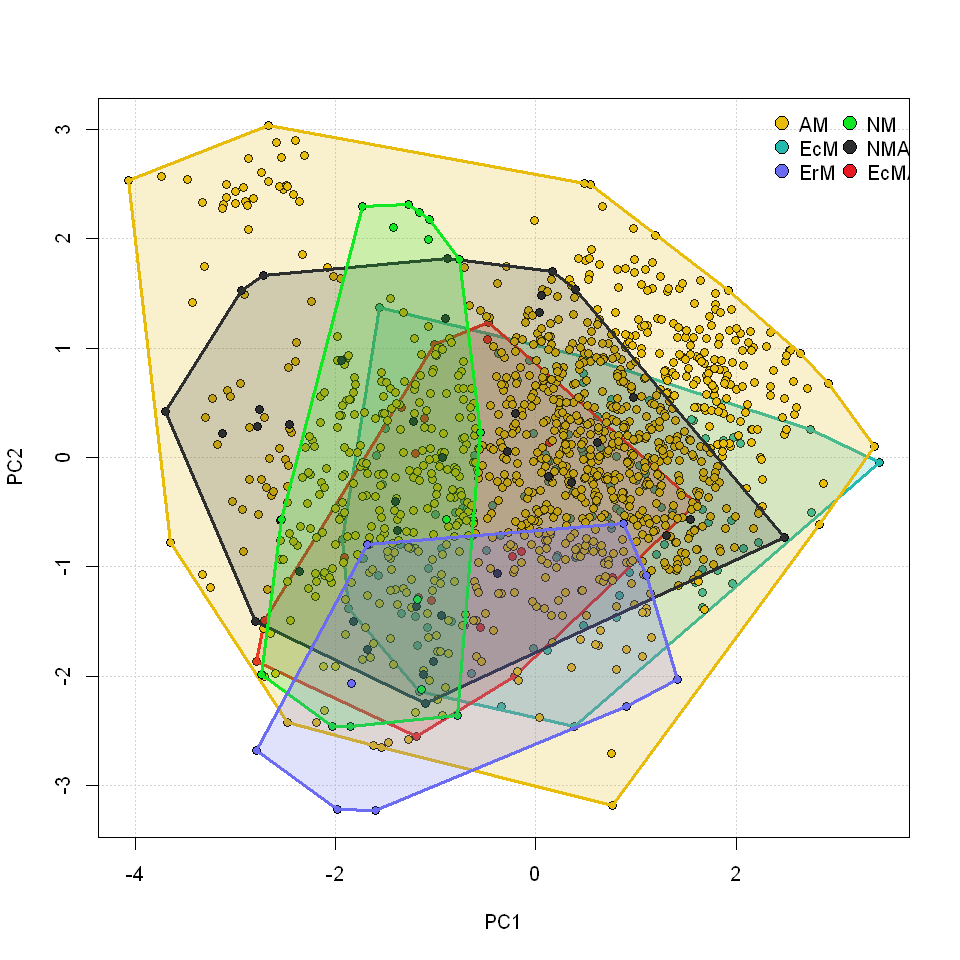

In [33]:
options(repr.plot.width = 8, repr.plot.height = 8)
# png(filename = "../../plots/ppca-states.png", width = 10, height = 10, units = "in", res = 500)

# the below line is just to draw the canvas
plot(ppcs$PC1, ppcs$PC2, xlab = "PC1", ylab = "PC2", pch = NA, panel.first = grid())#, add = TRUE) # overlay this on the rect instead of drawing a separate 

for (s in unique(ppcs$state)){
    scores <- subset(ppcs, state == s, select = c("PC1", "PC2")) # subset the dataframe to only include species of the choosen state
    points(scores$PC1, scores$PC2, pch = 21, bg = STATE_COLOURS[s])
    indices <- chull(x = scores$PC1, y = scores$PC2) # create the convex hull indices
    indices <- c(indices, indices[1])
    polygon(scores$PC1[indices], scores$PC2[indices], col = adjustcolor(STATE_COLOURS[s], alpha.f = 0.2), border = STATE_COLOURS[s], lwd = 2.5) # this will fill the convex hull with colour
    # lines(scores$PC1[indices], scores$PC2[indices], col = STATE_COLOURS[s], lwd = 2.5) # this will just draw a border around the polygon
}

legend(2.25, 3.3, legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 21, pt.cex = 1.5, horiz = FALSE, ncol = 2, bty = "n", y.intersp = 0.85, # vertical spacing between legend rows (row height)
       x.intersp = 0.8, # horizontal spacing between the marker and its text
       text.width = 0.3) # column width in the legend
# dev.off()

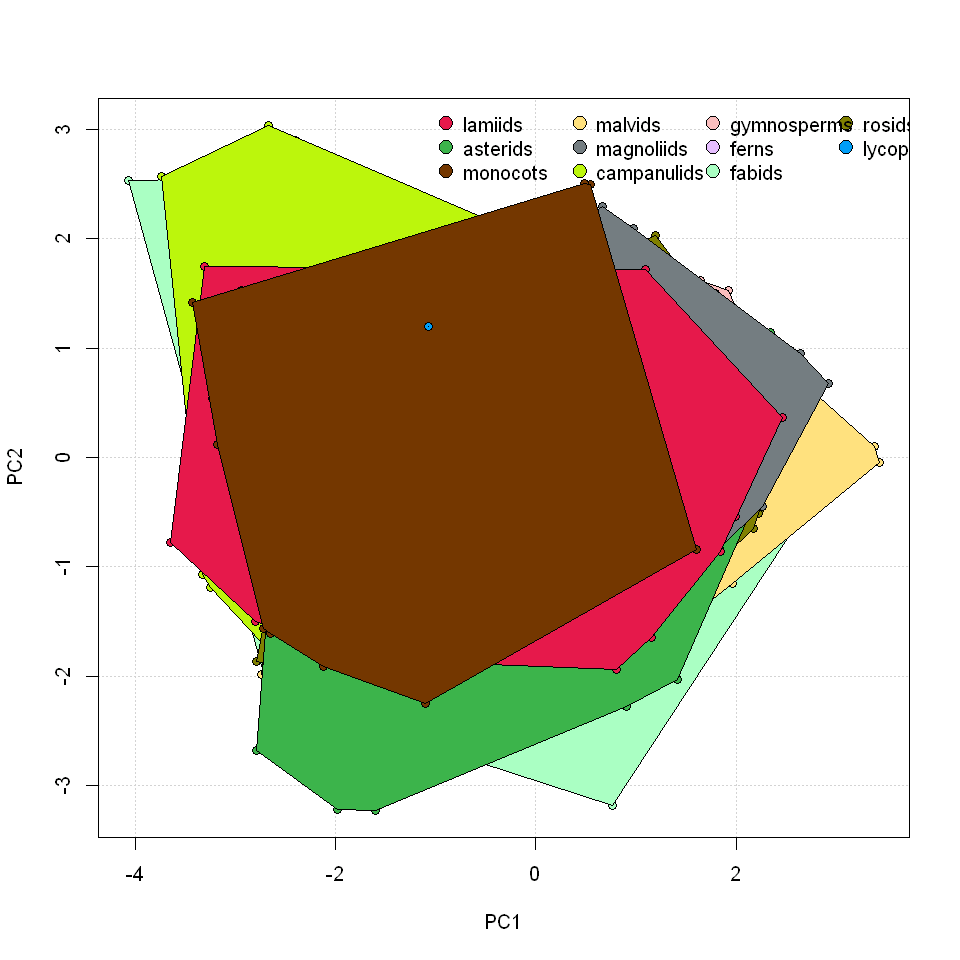

In [55]:
# grouping based on taxonomy
options(repr.plot.width = 8, repr.plot.height = 8)
# png(filename = "../../plots/ppca-apg4.png", width = 10, height = 10, units = "in", res = 500)

# REDEFINE HIGHER RANKS TO EXCLUDE ASTERIDS AND ROSIDS
APG4_HIGHER_RANKS <- c("superrosids", "superasterids", "eudicots", "angiosperms")

# CHOOSING ONLY TO VISUALIZE THE LOWER APG4 RANKS
ppcs_lower_ranks <- ppcs[!ppcs$group %in% APG4_HIGHER_RANKS, ]

plot(ppcs_lower_ranks$PC1, ppcs_lower_ranks$PC2, xlab = "PC1", ylab = "PC2", pch = NA, panel.first = grid())

for (g in unique(ppcs_lower_ranks$group)){
    scores <- subset(ppcs_lower_ranks, group == g, select = c("PC1", "PC2")) # subset the dataframe to only include species of the choosen state
    points(scores$PC1, scores$PC2, pch = 21, bg = APG4_COLOURS[g])
    indices <- chull(x = scores$PC1, y = scores$PC2) # create the convex hull indices
    indices <- c(indices, indices[1])
    polygon(scores$PC1[indices], scores$PC2[indices], lwd = 1.5, col = APG4_COLOURS[g], lty = 1)# ifelse(g %in% APG4_HIGHER_RANKS, 3, 1)) # plot the higer ranks with dotted lines
}

legend(x = -1.1, y = 3.3, legend = names(APG4_COLOURS[!names(APG4_COLOURS) %in% APG4_HIGHER_RANKS]), pt.bg = APG4_COLOURS[!names(APG4_COLOURS) %in% APG4_HIGHER_RANKS],
       pch = 21, pt.cex = 1.5, horiz = FALSE, ncol = 4, bty = "n", y.intersp = 0.85, x.intersp = 0.8, text.width = 0.95)
# dev.off()

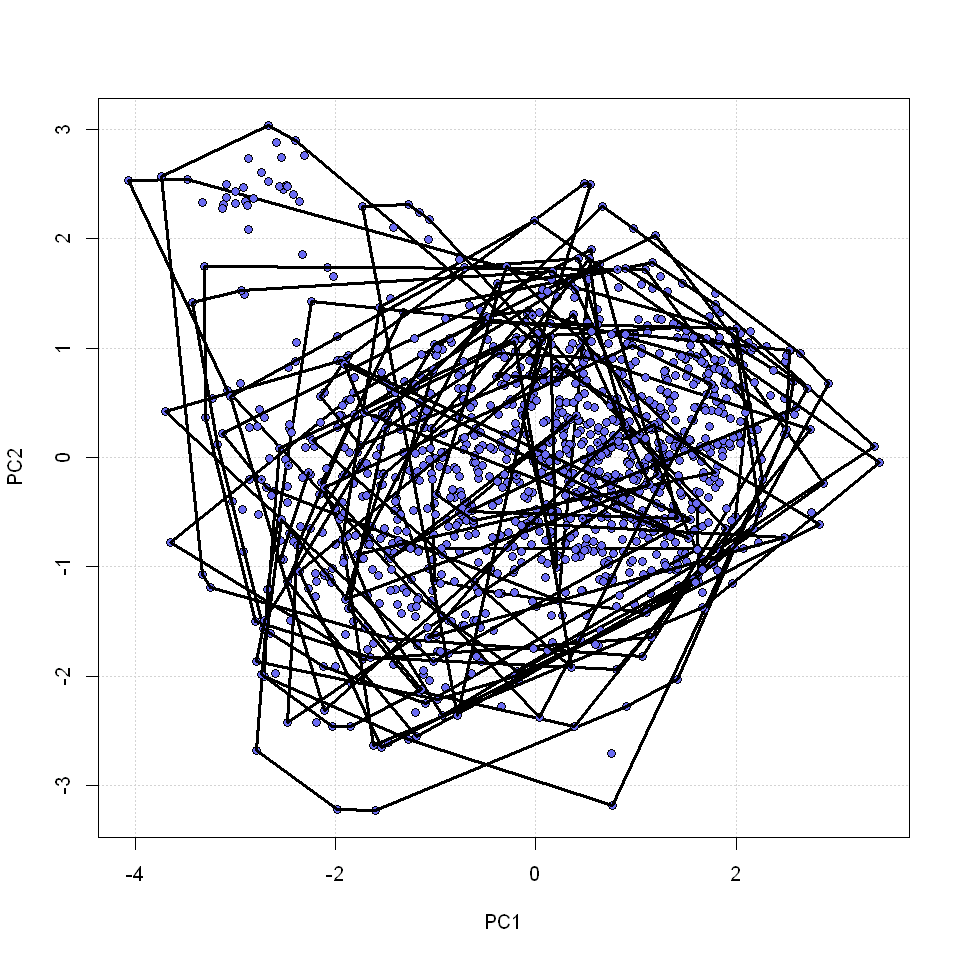

In [54]:
# try plotting by order instead - THERE ARE 42 ORDERS IN THE SUBSET THOUGH :/

ppcs_subset <- subset(ppcs, !is.na(order))
plot(ppcs_subset$PC1, ppcs_subset$PC2, xlab = "PC1", ylab = "PC2", pch = NA, panel.first = grid())

for (ord in unique(ppcs_subset$order)){
    scores <- subset(ppcs_subset, order == ord, select = c("PC1", "PC2"))
    points(scores$PC1, scores$PC2, pch = 21, bg = STATE_COLOURS[s])
    indices <- chull(x = scores$PC1, y = scores$PC2)
    indices <- c(indices, indices[1])
    polygon(scores$PC1[indices], scores$PC2[indices], lwd = 2.5)
}

In [56]:
#----------------------------------------
# plot both of the pPCA plots together
#----------------------------------------

# options(repr.plot.width = 16, repr.plot.height = 8)
png(filename = "../../plots/ppca-all.png", width = 20, height = 10, units = "in", res = 500)
par(mfcol = c(1, 2), mar = c(5, 5, 1, 1))

plot(ppcs$PC1, ppcs$PC2, xlab = "PC1", ylab = "PC2", pch = NA, panel.first = grid(), cex.lab = 1.5, cex.axis = 1.5)#, add = TRUE) # overlay this on the rect instead of drawing a separate 
for (s in unique(ppcs$state)){
    scores <- subset(ppcs, state == s, select = c("PC1", "PC2")) # subset the dataframe to only include species of the choosen state
    points(scores$PC1, scores$PC2, pch = 21, bg = STATE_COLOURS[s])
    indices <- chull(x = scores$PC1, y = scores$PC2) # create the convex hull indices
    indices <- c(indices, indices[1])
    polygon(scores$PC1[indices], scores$PC2[indices], col = adjustcolor(STATE_COLOURS[s], alpha.f = 0.1), border = STATE_COLOURS[s], lwd = 2.5)
}
legend(2.25, 3.3, legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 21, pt.cex = 1.5, horiz = FALSE, ncol = 2, bty = "n", y.intersp = 0.85, # vertical spacing between legend rows (row height)
       x.intersp = 0.8, # horizontal spacing between the marker and its text
       text.width = 0.3) # column width in the legend


# PLOT ONLY THE LOWER TAXONOMIC RANKS FROM APG4 SINCE THE HIGHER RANKS DO NOT INCLUDE THEIR LOWER RANKS - VISUALS CAN BECOME MISLEADING
APG4_HIGHER_RANKS <- c("superrosids", "superasterids", "eudicots", "angiosperms")
ppcs_lower_ranks <- ppcs[!ppcs$group %in% APG4_HIGHER_RANKS, ] # filtering the PPCA table for lower ranks

plot(ppcs_lower_ranks$PC1, ppcs_lower_ranks$PC2, xlab = "PC1", ylab = "PC2", pch = NA, panel.first = grid(), cex.lab = 1.5, cex.axis = 1.5)
for (g in unique(ppcs_lower_ranks$group)){
    scores <- subset(ppcs_lower_ranks, group == g, select = c("PC1", "PC2")) # subset the dataframe to only include species of the choosen state
    points(scores$PC1, scores$PC2, pch = 21, bg = APG4_COLOURS[g])
    indices <- chull(x = scores$PC1, y = scores$PC2) # create the convex hull indices
    indices <- c(indices, indices[1])
    polygon(scores$PC1[indices], scores$PC2[indices], col = adjustcolor(APG4_COLOURS[g], alpha.f = 0.1), border = APG4_COLOURS[g], lwd = 2.5, lty = 1) # ifelse(g %in% APG4_HIGHER_RANKS, 3, 1))
    # lines(scores$PC1[indices], scores$PC2[indices], lwd = 1.5, col = APG4_COLOURS[g], lty = ifelse(g %in% APG4_HIGHER_RANKS, 3, 1)) # plot the higer ranks with dotted lines
}
# only include the lower ranks in the legend
legend(x = -1.1, y = 3.3, legend = names(APG4_COLOURS[!names(APG4_COLOURS) %in% APG4_HIGHER_RANKS]),
       pt.bg = APG4_COLOURS[!names(APG4_COLOURS) %in% APG4_HIGHER_RANKS], pch = 21, pt.cex = 1.5, horiz = FALSE, ncol = 3, bty = "n", y.intersp = 0.85, x.intersp = 0.8, text.width = 0.95)

dev.off()

pdf 
  2

In [12]:
png(filename = "../../plots/ppca-states-supp.png", width = 30, height = 10, units = "in", res = 500, type = "cairo-png")
par(mfcol = c(1, 3), mar = c(5, 5, 1, 1))

for (pairs in list(c("PC1", "PC2"), c("PC1", "PC3"), c("PC2", "PC3"))){ # possible PC combinations
    
    pcs <- subset(ppcs, select = c(pairs, "state"))
    plot(x = pcs[, pairs[1]], y = pcs[, pairs[2]], xlab = pairs[1], ylab = pairs[2], pch = NA, panel.first = grid(), cex.axis = 1.5, cex.lab = 2)
    
    for (s in unique(pcs$state)){
        scores <- subset(pcs, state == s)
        points(scores[, pairs[1]], scores[, pairs[2]], pch = 21, bg = STATE_COLOURS[s])
        indices <- chull(x = scores[, pairs[1]], y = scores[, pairs[2]])
        indices <- c(indices, indices[1])
        polygon(scores[, pairs[1]][indices], scores[, pairs[2]][indices], col = adjustcolor(STATE_COLOURS[s], alpha.f = 0.1), border = STATE_COLOURS[s], lwd = 2.5)
    }
}

legend("topright", legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 21, pt.cex = 3.5, horiz = FALSE, ncol = 3, bty = "n", y.intersp = 1.5, x.intersp = 1.2, text.width = 0.4, cex = 1.5)
dev.off()

pdf 
  2

In [13]:
png(filename = "../../plots/ppca-taxa-supp.png", width = 30, height = 10, units = "in", res = 500, type = "cairo-png")
par(mfrow = c(1, 3), mar = c(5, 5, 1, 1))
# options(repr.plot.width = 30, repr.plot.height = 10)

for (pairs in list(c("PC1", "PC2"), c("PC1", "PC3"), c("PC2", "PC3"))){
    
    pcs <- subset(ppcs, select = c(pairs, "group"))
    plot(x = pcs[, pairs[1]], y = pcs[, pairs[2]], xlab = pairs[1], ylab = pairs[2], pch = NA, panel.first = grid(), cex.axis = 1.5, cex.lab = 2)
    
    for (g in unique(pcs$group)){
        scores <- subset(ppcs, group == g)
        points(scores[, pairs[1]], scores[, pairs[2]], pch = 21, bg = APG4_COLOURS[g])
        indices <- chull(x = scores[, pairs[1]], y = scores[, pairs[2]])
        indices <- c(indices, indices[1])
        polygon(scores[, pairs[1]][indices], scores[, pairs[2]][indices], col = adjustcolor(APG4_COLOURS[g], alpha.f = 0.1), border = APG4_COLOURS[g], lwd = 2.5, lty = ifelse(g %in% APG4_HIGHER_RANKS, 3, 1))
    }
}

legend("bottomright", legend = names(APG4_COLOURS), pt.bg = APG4_COLOURS, pch = 21, pt.cex = 3.5, horiz = FALSE, ncol = 4, bty = "n", y.intersp = 1.5, x.intersp = 1.2, text.width = 0.75, cex = 1.5)

dev.off()

pdf 
  2